<a href="https://colab.research.google.com/github/cahyoadi88/Script/blob/main/CNN%20-%20Deep%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset yang kita gunakan memiliki 192 sampel data latih yang terdiri dari 96 sampel gambar ruangan rapi dan 96 sampel gambar ruangan berantakan.

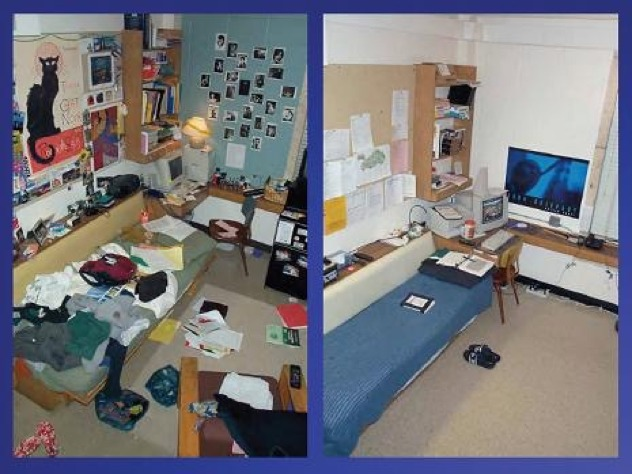

# IMPORT DATASET


In [1]:
import tensorflow as tf

In [2]:
!wget --no-check-certificate \
  https://github.com/dicodingacademy/assets/raw/main/ml_pemula_academy/messy-vs-clean-room.zip \
  -O /tmp/messy_vs_clean_room.zip

--2023-06-23 14:47:50--  https://github.com/dicodingacademy/assets/raw/main/ml_pemula_academy/messy-vs-clean-room.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dicodingacademy/assets/main/ml_pemula_academy/messy-vs-clean-room.zip [following]
--2023-06-23 14:47:50--  https://raw.githubusercontent.com/dicodingacademy/assets/main/ml_pemula_academy/messy-vs-clean-room.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 70392746 (67M) [application/zip]
Saving to: ‘/tmp/messy_vs_clean_room.zip’

/tmp/messy_vs_clean 100%[===================>]  67.13M   120MB/s    in 0.6s    

2023-06-23 14:47:51 

In [3]:
# melakukan ekstraksi pada file zip
import zipfile,os
local_zip = '/tmp/messy_vs_clean_room.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

base_dir = '/tmp/images'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')

In [4]:
os.listdir('/tmp/images/train')

['messy', 'clean']

In [5]:
os.listdir('/tmp/images/val')

['messy', 'clean']

# Prepocessing data dengan image augmentation

- **rescale** melakukan penskalaan ulang nilai piksel gambar ke rentang [0, 1]. Langkah normalisasi ini umumnya diterapkan pada data masukan dalam jaringan saraf.
- **rotation_range** melakukan rotasi acak pada gambar dengan maksimum rotasi sebesar x derajat. Hal ini memperkenalkan variasi pada data pelatihan dan membantu model dalam melakukan generalisasi yang lebih baik.
- **horizontal_flip** melakukan flipping horizontal acak pada gambar. Teknik augmentasi ini meningkatkan keberagaman data pelatihan.
- **shear_range** melakukan transformasi shear pada gambar. Transformasi shear mengubah bentuk objek pada gambar dan menambahkan variasi lainnya.
- **fill_mode**  mengisi piksel yang mungkin kosong setelah dilakukan transformasi dengan nilai piksel terdekat. Hal ini memastikan bahwa gambar hasil augmentasi memiliki ukuran yang sama dengan gambar asli.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=20,
    horizontal_flip= True,
    shear_range=0.2,
fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
                    rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_directory(
        train_dir,  # direktori data latih
        target_size=(150, 150),  # mengubah resolusi seluruh gambar menjadi 150x150 piksel
        batch_size=4,
        # karena ini merupakan masalah klasifikasi 2 kelas maka menggunakan class_mode = 'binary'
        class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
        validation_dir, # direktori data validasi
        target_size=(150, 150), # mengubah resolusi seluruh gambar menjadi 150x150 piksel
        batch_size=4,
        # karena ini merupakan masalah klasifikasi 2 kelas maka menggunakan class_mode = 'binary'
        class_mode='binary')

Found 192 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [9]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['accuracy'])

In [10]:
history = model.fit(
      train_generator,
      steps_per_epoch=25,  # berapa batch yang akan dieksekusi pada setiap epoch
      epochs=32,
      validation_data=validation_generator, # menampilkan akurasi pengujian data validasi
      validation_steps=5,  # berapa batch yang akan dieksekusi pada setiap epoch
      verbose=2)

Epoch 1/32
25/25 - 12s - loss: 1.3005 - accuracy: 0.6300 - val_loss: 0.5772 - val_accuracy: 0.7000 - 12s/epoch - 483ms/step
Epoch 2/32
25/25 - 1s - loss: 0.6589 - accuracy: 0.6800 - val_loss: 0.7570 - val_accuracy: 0.5000 - 963ms/epoch - 39ms/step
Epoch 3/32
25/25 - 2s - loss: 0.6642 - accuracy: 0.4800 - val_loss: 0.5839 - val_accuracy: 0.5500 - 2s/epoch - 64ms/step
Epoch 4/32
25/25 - 1s - loss: 0.6017 - accuracy: 0.7500 - val_loss: 0.5056 - val_accuracy: 0.7000 - 1s/epoch - 55ms/step
Epoch 5/32
25/25 - 1s - loss: 0.6004 - accuracy: 0.6400 - val_loss: 0.5369 - val_accuracy: 0.8000 - 941ms/epoch - 38ms/step
Epoch 6/32
25/25 - 1s - loss: 0.5202 - accuracy: 0.7500 - val_loss: 0.4105 - val_accuracy: 0.7500 - 933ms/epoch - 37ms/step
Epoch 7/32
25/25 - 1s - loss: 0.4594 - accuracy: 0.8200 - val_loss: 0.5388 - val_accuracy: 0.6500 - 981ms/epoch - 39ms/step
Epoch 8/32
25/25 - 1s - loss: 0.5502 - accuracy: 0.7500 - val_loss: 0.5029 - val_accuracy: 0.7500 - 932ms/epoch - 37ms/step
Epoch 9/32
25/

DATA TEST

[donwload gambar data test](https://drive.google.com/drive/folders/1yofkHvWvS2_motkYxeI9s4GfCcHqgChK)


Saving NPWP.jpg to NPWP.jpg
1/1 [==============================] - 0s 182ms/step
NPWP.jpg
messy


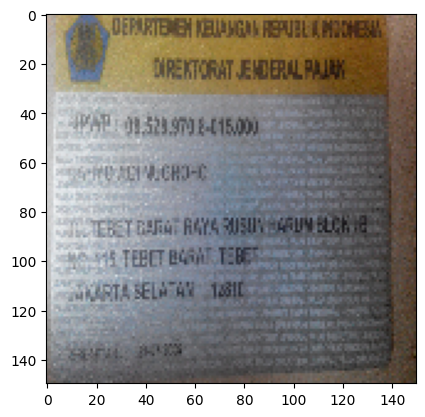

In [11]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = fn
  img = image.load_img(path, target_size=(150,150))

  imgplot = plt.imshow(img)
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  images = np.vstack([x])

  classes = model.predict(images, batch_size=10)
  print(fn)
  if classes==1:
   print('messy')
  else:
   print('clean')